In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import os
import seaborn as sns  
import glob

from collections import Counter

from dotenv import load_dotenv; load_dotenv()

from utils import preprocessing
from utils import DEG
from utils import label_mapping_utils as lmu
from utils import nebula_with_factors as deg_nebula

from statsmodels.stats.multitest import multipletests
import gseapy as gp
from gseapy import dotplot, barplot, gseaplot2
import shutil

import decoupler as dc

# ATTENTION: need for perpty of running jupternotbook
%matplotlib inline

ADATA_PATH = "/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/Striatum/Striatum_combined_QC_mmc_ct-cured_zoned.h5ad"



# Cell Types
ct_cols = ["Curated Labels", "Group_name"]
               
# Histogrmans
qc_cols = ["frac_intronic", "background_fraction",'cell_size', "dropsift_frac_contamination"]
    
# Sample level covariates
# name of Sample varibale
SAMPLE_VARIABLE = "donor_id"
# variable to test if differtially epxresseda
CONTRAST_VARIABLE = "condition"
# Level of contrat varibale to use as baseline
CONTRAST_BASELINE = "Control"
# Level of contrat varibale to use as stimulated
CONTRAST_STIM = "XDP"

sample_cols = ["sex", "condition", "has_spatial", "age_of_death", SAMPLE_VARIABLE]

In [2]:
adata = sc.read_h5ad(ADATA_PATH)
adata

AnnData object with n_obs × n_vars = 231080 × 38601
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'barcode', 'bcl', 'rna_index', 'library', 'library__barcode', 'frac_mito', 'mol_info_nUMI', 'mol_info_nRead', 'frac_intronic', 'donor_id', 'vireo_prob_max', 'vireo_prob_doublet', 'vireo_n_vars', 'vireo_best_singlet', 'vireo_best_doublet', 'vireo_doublet_logLikRatio', 'dropsift_frac_contamination', 'dropsift_training_label_is_cell', 'dropsift_empty_gene_module_score', 'dropsift_is_cell', 'dropsift_is_cell_prob', 'cell_class', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'tissue', 'broad_original_cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'brain_bank', 'cohort', 'condition', 'sex', 'age_of_on

In [17]:
adata.obs.rename(columns={"ct_for_deg": "Curated Labels"}, inplace=True)
adata.obs.rename(columns={"age_of_death": "Age"}, inplace=True)

In [5]:
NAME = "only_MSN"

STR_ct = ["Patch_D1", "Patch_D2", "Matrix_D1", "Matrix_D2", "eMSN_D1D2", "eMSN_StrioMat", "eMSN_NUDAP", "-TAFA1"]
a = adata[adata.obs["Curated Labels"].isin(STR_ct)].to_memory().copy()

leiden_cluster_names = lmu.preprocess_common_pipeline(a, umap_name=NAME, leiden_name=NAME, resolutions = [0.1, 0.5, 1.0], integrate_with_harmony=True, batch_key=SAMPLE_VARIABLE)

INFO: Seed set to 42
2026-05-13 15:07:34 | [INFO] Seed set to 42


Running HVG...
HVG computed with batch_key='donor_id'
Subsetting to copy with only HVG...
Scaling ...


/home/gdallagl/.pyenv/versions/3.11.8/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Running Harmony...
Running PCA before Harmony...


2026-05-13 15:08:03,193 - harmonypy - INFO - Running Harmony (PyTorch on cuda)
2026-05-13 15:08:03 | [INFO] Running Harmony (PyTorch on cuda)
2026-05-13 15:08:03,195 - harmonypy - INFO -   Parameters:
2026-05-13 15:08:03 | [INFO]   Parameters:
2026-05-13 15:08:03,196 - harmonypy - INFO -     max_iter_harmony: 30
2026-05-13 15:08:03 | [INFO]     max_iter_harmony: 30
2026-05-13 15:08:03,197 - harmonypy - INFO -     max_iter_kmeans: 20
2026-05-13 15:08:03 | [INFO]     max_iter_kmeans: 20
2026-05-13 15:08:03,198 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-05-13 15:08:03 | [INFO]     epsilon_cluster: 1e-05
2026-05-13 15:08:03,198 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-05-13 15:08:03 | [INFO]     epsilon_harmony: 0.0001
2026-05-13 15:08:03,199 - harmonypy - INFO -     nclust: 100
2026-05-13 15:08:03 | [INFO]     nclust: 100
2026-05-13 15:08:03,200 - harmonypy - INFO -     block_size: 0.05
2026-05-13 15:08:03 | [INFO]     block_size: 0.05
2026-05-13 15:08:03,201 - harm

Running Harmony batch correction...


2026-05-13 15:08:03,679 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-05-13 15:08:03 | [INFO] Computing initial centroids with sklearn.KMeans...
2026-05-13 15:08:04,508 - harmonypy - INFO - KMeans initialization complete.
2026-05-13 15:08:04 | [INFO] KMeans initialization complete.
2026-05-13 15:08:04,688 - harmonypy - INFO - Iteration 1 of 30
2026-05-13 15:08:04 | [INFO] Iteration 1 of 30
2026-05-13 15:08:06,106 - harmonypy - INFO - Iteration 2 of 30
2026-05-13 15:08:06 | [INFO] Iteration 2 of 30
2026-05-13 15:08:07,371 - harmonypy - INFO - Iteration 3 of 30
2026-05-13 15:08:07 | [INFO] Iteration 3 of 30
2026-05-13 15:08:08,625 - harmonypy - INFO - Iteration 4 of 30
2026-05-13 15:08:08 | [INFO] Iteration 4 of 30
2026-05-13 15:08:09,903 - harmonypy - INFO - Iteration 5 of 30
2026-05-13 15:08:09 | [INFO] Iteration 5 of 30
2026-05-13 15:08:10,836 - harmonypy - INFO - Iteration 6 of 30
2026-05-13 15:08:10 | [INFO] Iteration 6 of 30
2026-05-13 15:08:11,629 - 

Z_corr shape: (36130, 50), n_obs: 36130
Computing neighbors on Harmony-corrected PCA...
Computing UMAP...
Computing Leiden clusters...


# Cell "types" counts

### In total

Unique values in Curated Labels: ['-Low_quality', 'Astrocyte', 'SmoothMuscleCells', 'Endothelial_BBB', 'Fibroblasts', ..., '-TAFA1', 'eMSN_NUDAP', 'OPC', 'COP', 'Oligodendrocyte']
Length: 23
Categories (23, object): ['-Low_quality', '-TAFA1', 'Astrocyte', 'COP', ..., 'eMSN_D1D2', 'eMSN_NUDAP', 'eMSN_StrioMat', 'non-MSN']


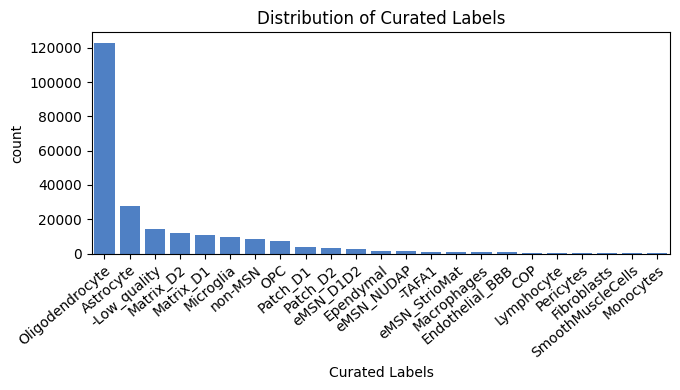

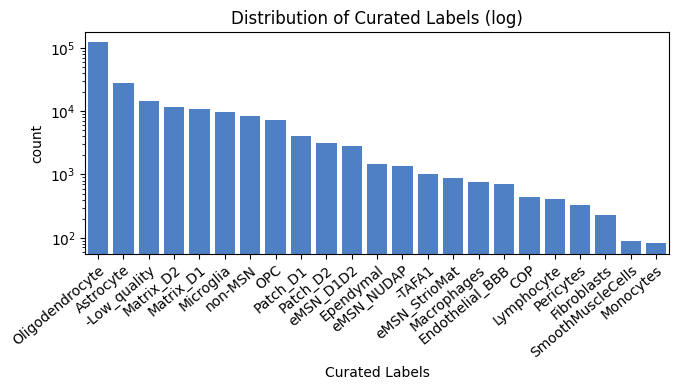

,count,proportion
Curated Labels,,
Oligodendrocyte,122867,0.531708
Astrocyte,27715,0.119937
-Low_quality,14435,0.062468
Matrix_D2,11745,0.050827
Matrix_D1,11037,0.047763
Microglia,9868,0.042704
non-MSN,8335,0.036070
OPC,7219,0.031240
Patch_D1,4098,0.017734


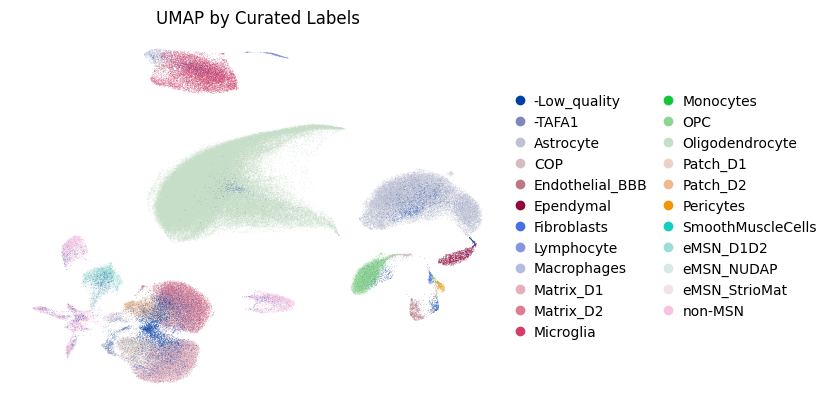

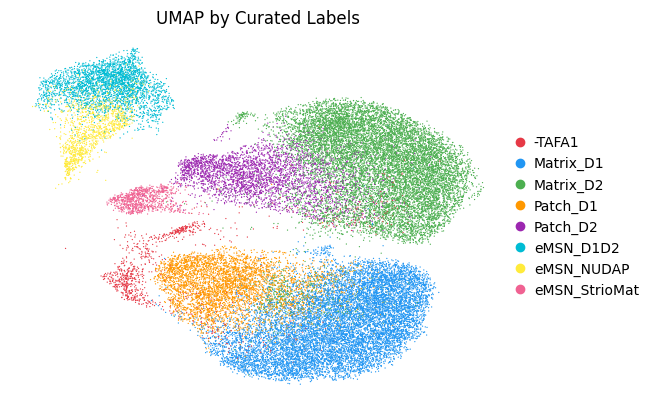

Unique values in Group_name: ['Astrocyte', 'ImAstro', 'OPC', 'VLMC', 'ImOligo', ..., 'Oligo OPALIN', 'GPi Shell', 'SN SEMA5A GABA', 'COP', 'Oligo PLEKHG1']
Length: 54
Categories (54, object): ['AMY-SLEA-BNST D1 GABA', 'AMY-SLEA-BNST GABA', 'Astrocyte', 'B cells', ..., 'VIP GABA', 'VLMC', 'VTR-HTH Glut', 'ZI-HTH GABA']


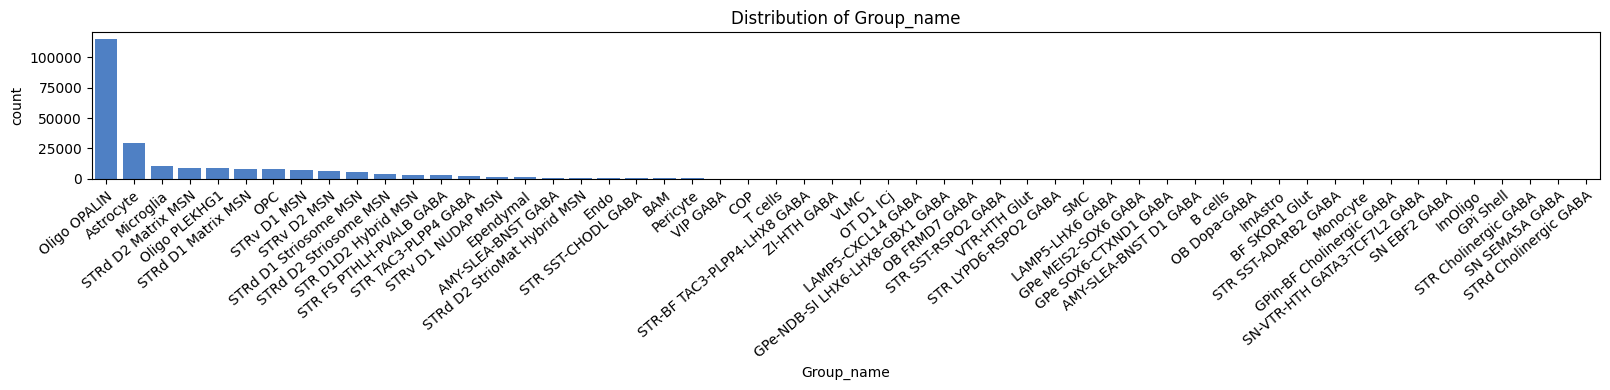

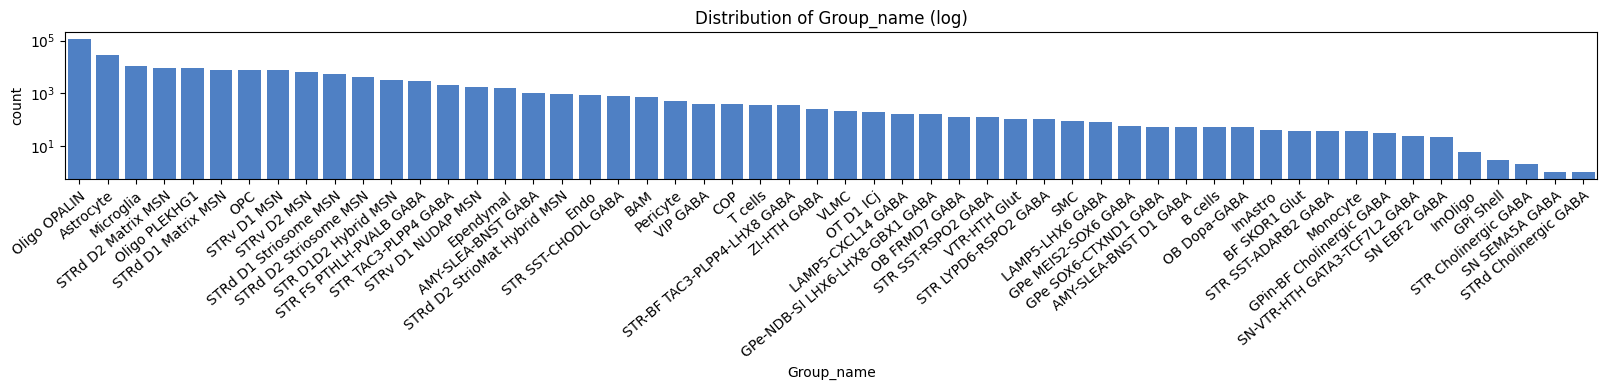

,count,proportion
Group_name,,
Oligo OPALIN,114527,0.495616
Astrocyte,29320,0.126882
Microglia,10592,0.045837
STRd D2 Matrix MSN,9321,0.040337
Oligo PLEKHG1,8841,0.038259
STRd D1 Matrix MSN,7896,0.034170
OPC,7781,0.033672
STRv D1 MSN,7418,0.032101
STRv D2 MSN,6271,0.027138


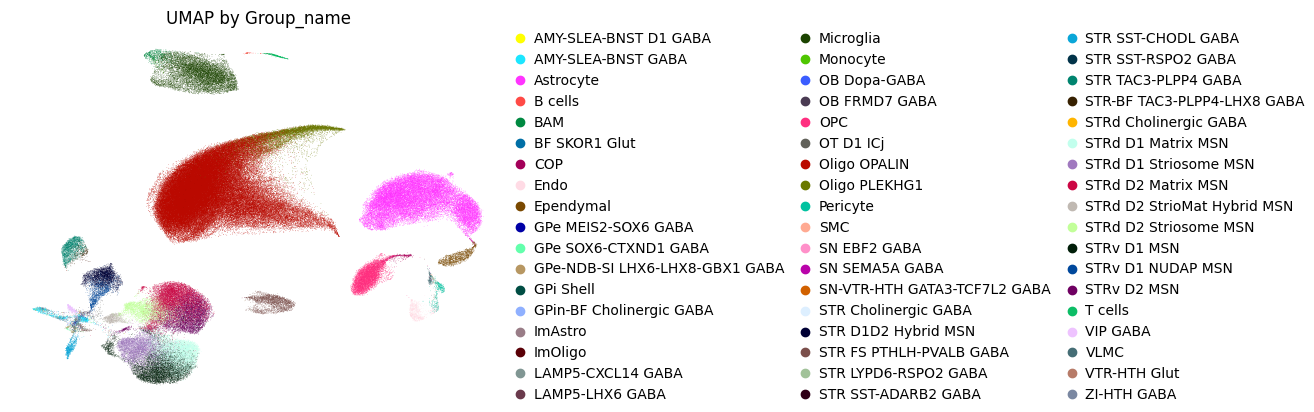

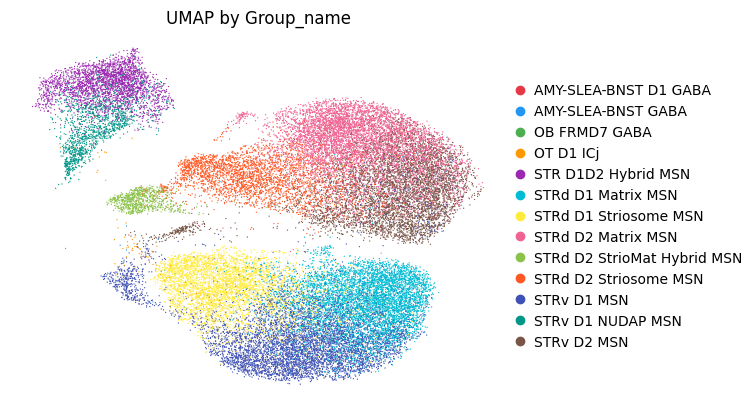

In [31]:
for col in ct_cols:
    print(f"Unique values in {col}:", adata.obs[col].unique())

    counts = adata.obs[col].value_counts()
    order = counts.index
    n = len(order)
    figsize = (min(18, max(4, n * 0.3)), 4)

    # counts
    plt.figure(figsize=figsize)
    sns.countplot(x=adata.obs[col], order=order, color="#3B7DD8")
    plt.xticks(rotation=40, ha="right", rotation_mode="anchor")
    plt.title(f"Distribution of {col}")
    plt.tight_layout(); plt.show()

    # counts, log scale
    plt.figure(figsize=figsize)
    sns.countplot(x=adata.obs[col], order=order, color="#3B7DD8")
    plt.xticks(rotation=40, ha="right", rotation_mode="anchor")
    plt.yscale("log")
    plt.title(f"Distribution of {col} (log)")
    plt.tight_layout(); plt.show()

    # proportions table
    tbl = adata.obs[col].value_counts().to_frame("count")
    tbl["proportion"] = tbl["count"] / tbl["count"].sum()
    display(tbl)

    # Umap
    groups_to_plot = list( set(adata.obs[col].unique()) - set(["-Mito_cluster_patch"]))
    sc.pl.embedding(adata, "umap", color=col, title=f"UMAP by {col}", frameon=False)

    # Umap Only MSN
    sc.pl.embedding(a, "umap", color=col, title=f"UMAP by {col}", frameon=False, palette=preprocessing.custom_palette)

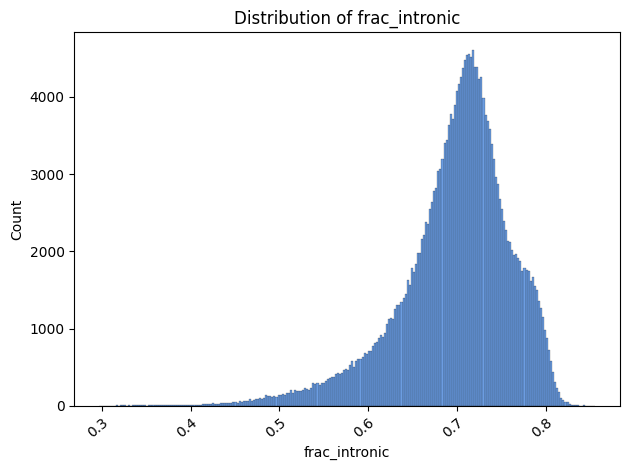

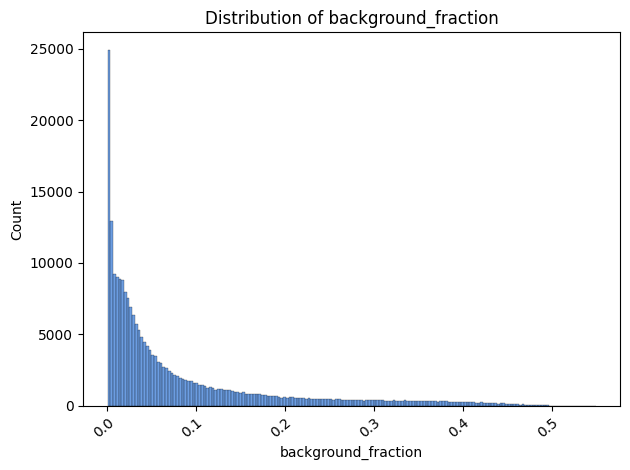

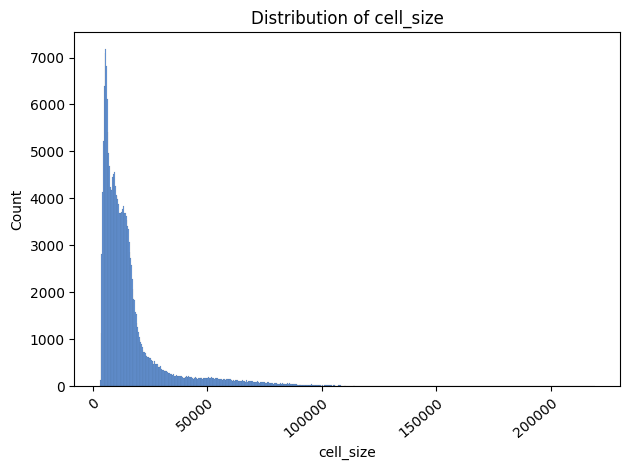

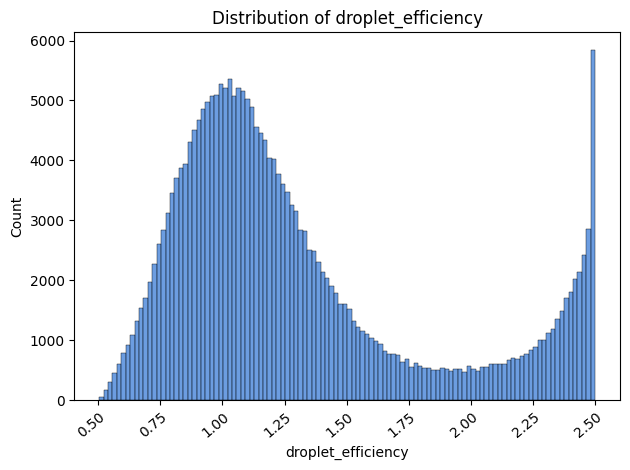

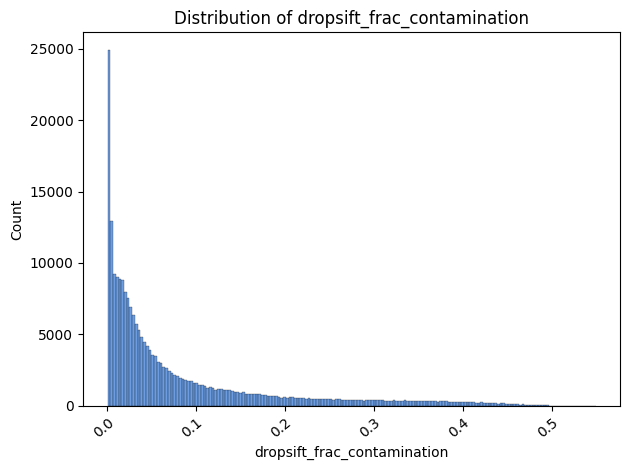

In [14]:
for col in qc_cols:

    plt.figure()
    sns.histplot(x=adata.obs[col], color="#3B7DD8")
    plt.xticks(rotation=40, ha="right", rotation_mode="anchor")
    plt.title(f"Distribution of {col}")
    plt.tight_layout(); plt.show()

In [ ]:
# zone are separeted as each cell type has its own zones

'mapping_coupling_for_zoning', 'zone', 'zone_probability', 'mapping_coupling_for_zoning_4_zones', 'zone_4', 'zone_4_probability'

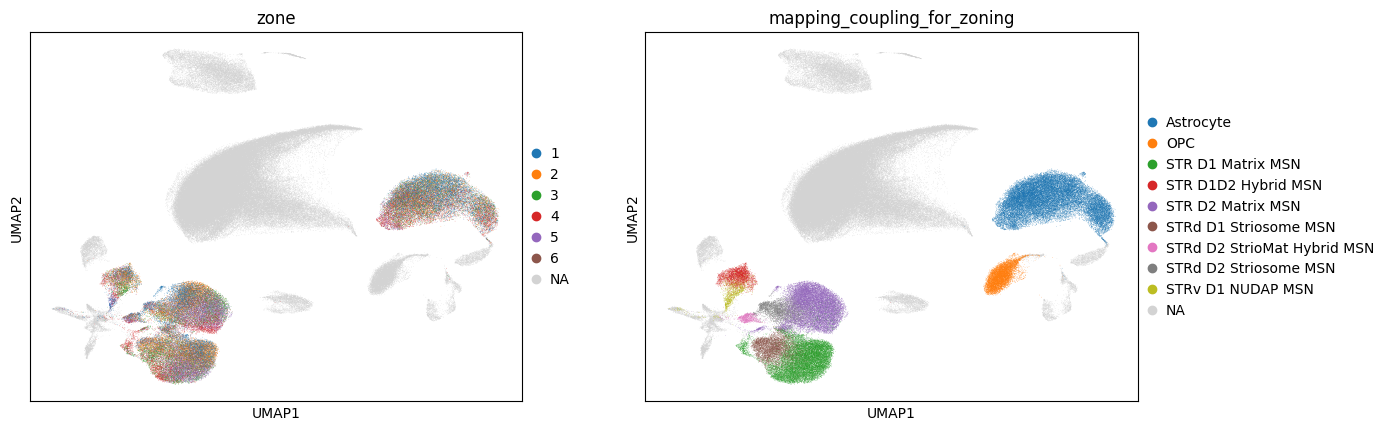

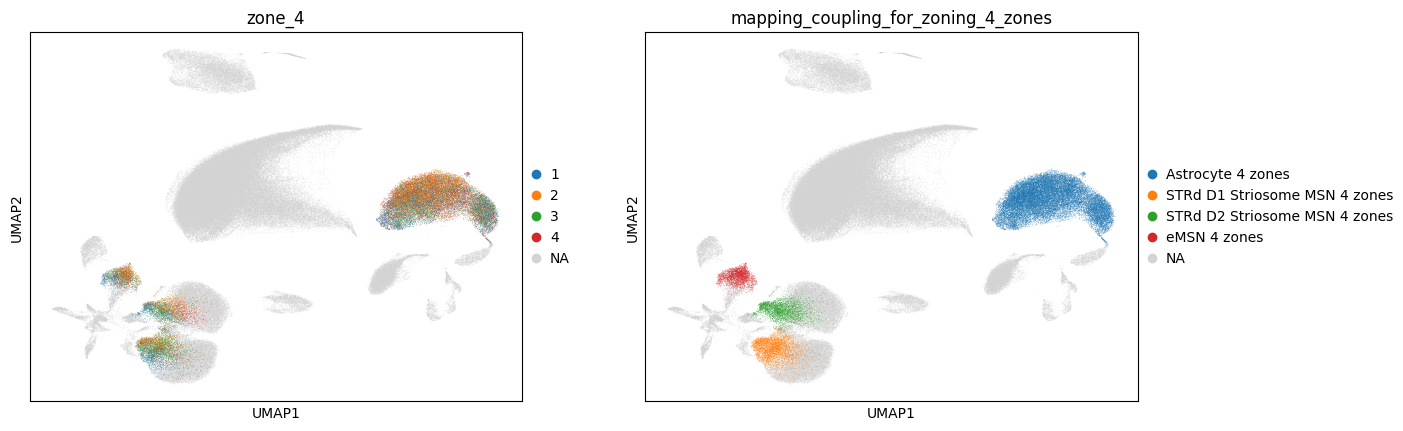

In [23]:
sc.pl.umap(adata, color=["zone", "mapping_coupling_for_zoning"])
sc.pl.umap(adata, color=["zone_4", "mapping_coupling_for_zoning_4_zones"])

#sc.pl.embedding(adata, basis="spatial", color=[OBS_COL_ZONE, CT_GROUPING_TO_MAP], size=10)

Matrix_D1 ['STRd D1 Matrix MSN', 'STRv D1 MSN']


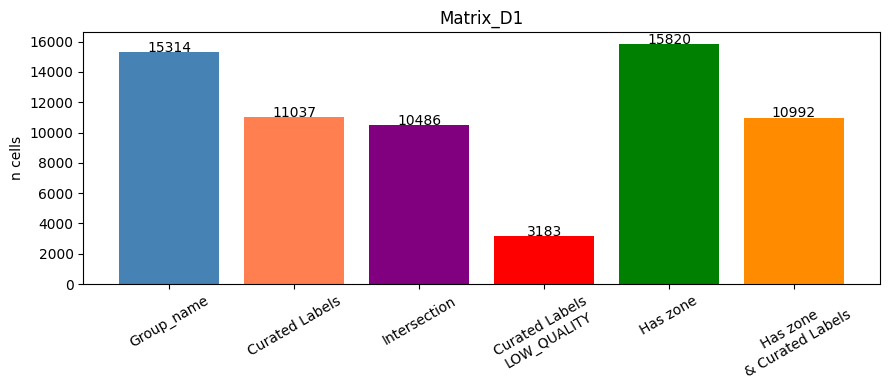

2026-05-13 16:08:07 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-13 16:08:07 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


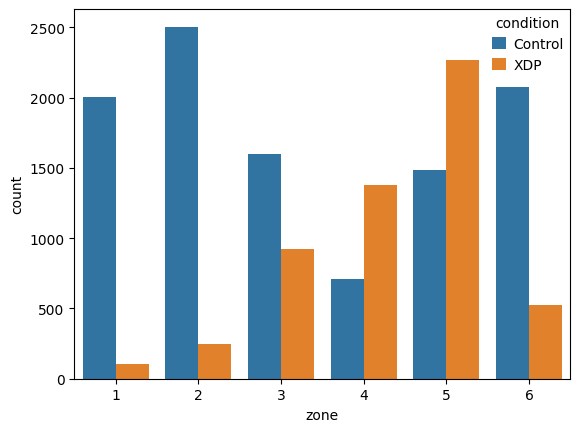

INFO: Seed set to 42
2026-05-13 16:08:10 | [INFO] Seed set to 42


Running HVG...
Subsetting to copy with only HVG...
Scaling ...


/home/gdallagl/.pyenv/versions/3.11.8/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Running Harmony...
Running PCA before Harmony...


2026-05-13 16:08:19,695 - harmonypy - INFO - Running Harmony (PyTorch on cuda)
2026-05-13 16:08:19 | [INFO] Running Harmony (PyTorch on cuda)
2026-05-13 16:08:19,697 - harmonypy - INFO -   Parameters:
2026-05-13 16:08:19 | [INFO]   Parameters:
2026-05-13 16:08:19,702 - harmonypy - INFO -     max_iter_harmony: 30
2026-05-13 16:08:19 | [INFO]     max_iter_harmony: 30
2026-05-13 16:08:19,706 - harmonypy - INFO -     max_iter_kmeans: 20
2026-05-13 16:08:19 | [INFO]     max_iter_kmeans: 20
2026-05-13 16:08:19,708 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-05-13 16:08:19 | [INFO]     epsilon_cluster: 1e-05
2026-05-13 16:08:19,713 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-05-13 16:08:19 | [INFO]     epsilon_harmony: 0.0001
2026-05-13 16:08:19,716 - harmonypy - INFO -     nclust: 100
2026-05-13 16:08:19 | [INFO]     nclust: 100
2026-05-13 16:08:19,718 - harmonypy - INFO -     block_size: 0.05
2026-05-13 16:08:19 | [INFO]     block_size: 0.05
2026-05-13 16:08:19,720 - harm

Running Harmony batch correction...


2026-05-13 16:08:20,009 - harmonypy - INFO - KMeans initialization complete.
2026-05-13 16:08:20 | [INFO] KMeans initialization complete.
2026-05-13 16:08:20,013 - harmonypy - INFO - Iteration 1 of 30
2026-05-13 16:08:20 | [INFO] Iteration 1 of 30
2026-05-13 16:08:21,262 - harmonypy - INFO - Iteration 2 of 30
2026-05-13 16:08:21 | [INFO] Iteration 2 of 30
2026-05-13 16:08:22,507 - harmonypy - INFO - Iteration 3 of 30
2026-05-13 16:08:22 | [INFO] Iteration 3 of 30
2026-05-13 16:08:23,746 - harmonypy - INFO - Iteration 4 of 30
2026-05-13 16:08:23 | [INFO] Iteration 4 of 30
2026-05-13 16:08:24,700 - harmonypy - INFO - Iteration 5 of 30
2026-05-13 16:08:24 | [INFO] Iteration 5 of 30
2026-05-13 16:08:25,462 - harmonypy - INFO - Iteration 6 of 30
2026-05-13 16:08:25 | [INFO] Iteration 6 of 30
2026-05-13 16:08:26,163 - harmonypy - INFO - Iteration 7 of 30
2026-05-13 16:08:26 | [INFO] Iteration 7 of 30
2026-05-13 16:08:26,864 - harmonypy - INFO - Iteration 8 of 30
2026-05-13 16:08:26 | [INFO] 

Z_corr shape: (11037, 50), n_obs: 11037
Computing neighbors on Harmony-corrected PCA...
Computing UMAP...
Computing Leiden clusters...


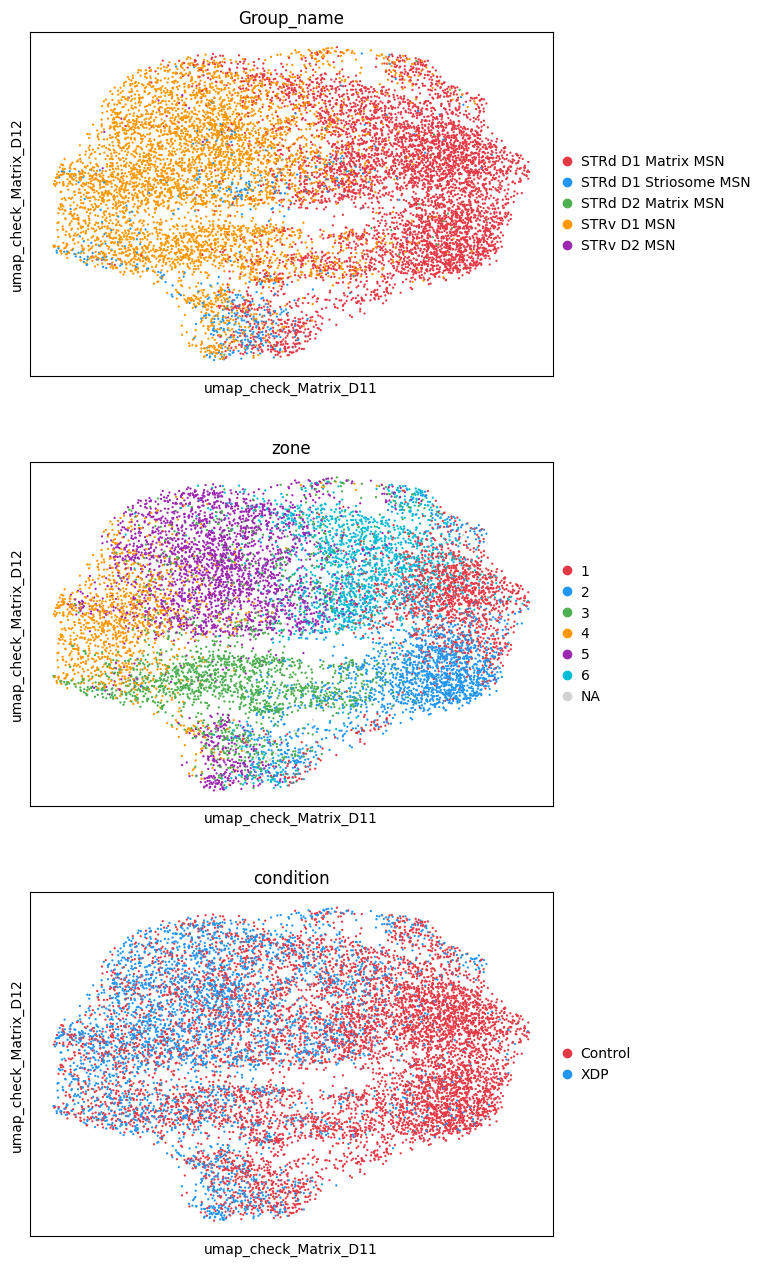

Matrix_D2 ['STRd D2 Matrix MSN', 'STRv D2 MSN']


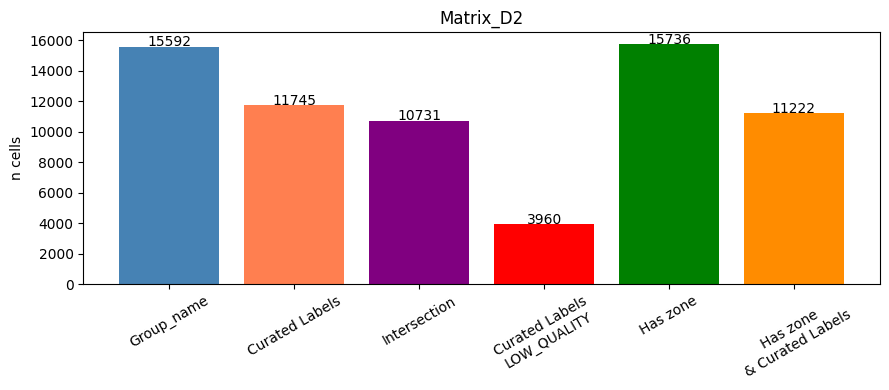

2026-05-13 16:08:50 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-13 16:08:50 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


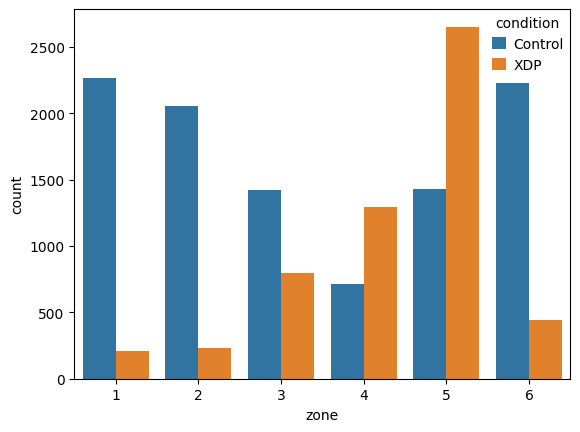

INFO: Seed set to 42
2026-05-13 16:08:53 | [INFO] Seed set to 42


Running HVG...
Subsetting to copy with only HVG...
Scaling ...


/home/gdallagl/.pyenv/versions/3.11.8/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Running Harmony...
Running PCA before Harmony...


2026-05-13 16:09:04,939 - harmonypy - INFO - Running Harmony (PyTorch on cuda)
2026-05-13 16:09:04 | [INFO] Running Harmony (PyTorch on cuda)
2026-05-13 16:09:04,940 - harmonypy - INFO -   Parameters:
2026-05-13 16:09:04 | [INFO]   Parameters:
2026-05-13 16:09:04,941 - harmonypy - INFO -     max_iter_harmony: 30
2026-05-13 16:09:04 | [INFO]     max_iter_harmony: 30
2026-05-13 16:09:04,942 - harmonypy - INFO -     max_iter_kmeans: 20
2026-05-13 16:09:04 | [INFO]     max_iter_kmeans: 20
2026-05-13 16:09:04,943 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-05-13 16:09:04 | [INFO]     epsilon_cluster: 1e-05
2026-05-13 16:09:04,944 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-05-13 16:09:04 | [INFO]     epsilon_harmony: 0.0001
2026-05-13 16:09:04,945 - harmonypy - INFO -     nclust: 100
2026-05-13 16:09:04 | [INFO]     nclust: 100
2026-05-13 16:09:04,946 - harmonypy - INFO -     block_size: 0.05
2026-05-13 16:09:04 | [INFO]     block_size: 0.05
2026-05-13 16:09:04,947 - harm

Running Harmony batch correction...


2026-05-13 16:09:05,258 - harmonypy - INFO - KMeans initialization complete.
2026-05-13 16:09:05 | [INFO] KMeans initialization complete.
2026-05-13 16:09:05,262 - harmonypy - INFO - Iteration 1 of 30
2026-05-13 16:09:05 | [INFO] Iteration 1 of 30
2026-05-13 16:09:06,551 - harmonypy - INFO - Iteration 2 of 30
2026-05-13 16:09:06 | [INFO] Iteration 2 of 30
2026-05-13 16:09:07,833 - harmonypy - INFO - Iteration 3 of 30
2026-05-13 16:09:07 | [INFO] Iteration 3 of 30
2026-05-13 16:09:09,142 - harmonypy - INFO - Iteration 4 of 30
2026-05-13 16:09:09 | [INFO] Iteration 4 of 30
2026-05-13 16:09:10,326 - harmonypy - INFO - Iteration 5 of 30
2026-05-13 16:09:10 | [INFO] Iteration 5 of 30
2026-05-13 16:09:11,158 - harmonypy - INFO - Iteration 6 of 30
2026-05-13 16:09:11 | [INFO] Iteration 6 of 30
2026-05-13 16:09:12,052 - harmonypy - INFO - Iteration 7 of 30
2026-05-13 16:09:12 | [INFO] Iteration 7 of 30
2026-05-13 16:09:13,042 - harmonypy - INFO - Iteration 8 of 30
2026-05-13 16:09:13 | [INFO] 

Z_corr shape: (11782, 50), n_obs: 11782
Computing neighbors on Harmony-corrected PCA...
Computing UMAP...
Computing Leiden clusters...


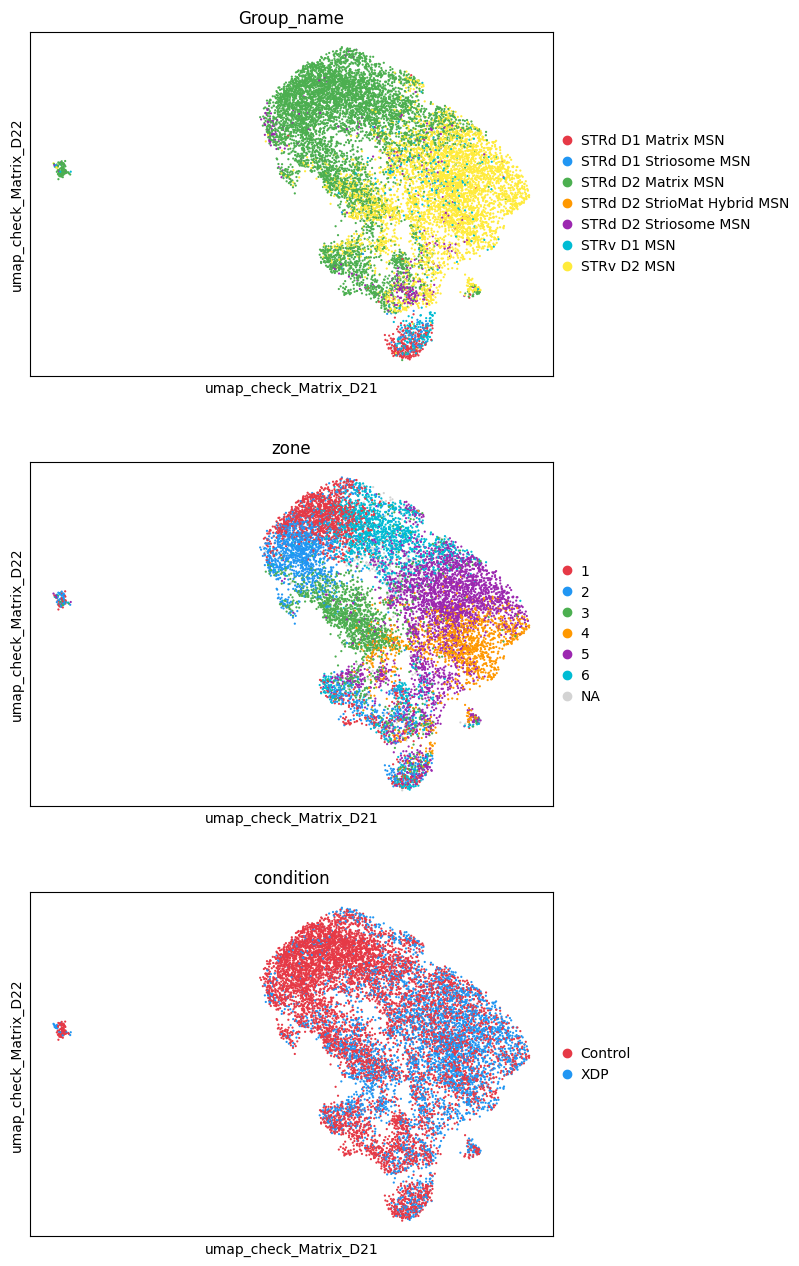

Patch_D1 ['STRd D1 Striosome MSN']


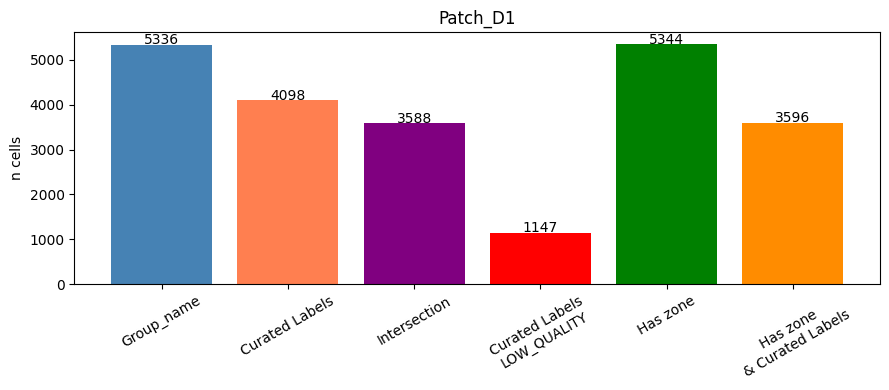

2026-05-13 16:09:31 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-13 16:09:31 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


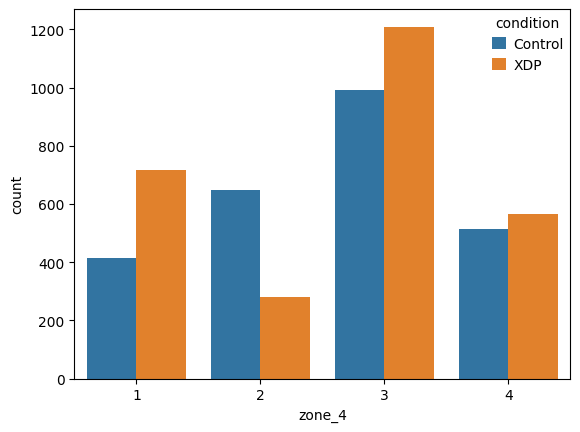

INFO: Seed set to 42
2026-05-13 16:09:32 | [INFO] Seed set to 42


Running HVG...
Subsetting to copy with only HVG...
Scaling ...
Running Harmony...
Running PCA before Harmony...


/home/gdallagl/.pyenv/versions/3.11.8/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
2026-05-13 16:09:37,468 - harmonypy - INFO - Running Harmony (PyTorch on cuda)
2026-05-13 16:09:37 | [INFO] Running Harmony (PyTorch on cuda)
2026-05-13 16:09:37,470 - harmonypy - INFO -   Parameters:
2026-05-13 16:09:37 | [INFO]   Parameters:
2026-05-13 16:09:37,471 - harmonypy - INFO -     max_iter_harmony: 30
2026-05-13 16:09:37 | [INFO]     max_iter_harmony: 30
2026-05-13 16:09:37,472 - harmonypy - INFO -     max_iter_kmeans: 20
2026-05-13 16:09:37 | [INFO]     max_iter_kmeans: 20
2026-05-13 16:09:37,473 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-05-13 16:09:37 | [INFO]     epsilon_cluster: 1e-05
2026-05-13 16:09:37,474 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-05-13 16:09:37 | [INFO]     epsilon_harmony: 0.0001
2026-05-13 16:09:37,475 - harmonypy - INFO -     nclust: 100
2026-0

Running Harmony batch correction...


2026-05-13 16:09:38,822 - harmonypy - INFO - Iteration 2 of 30
2026-05-13 16:09:38 | [INFO] Iteration 2 of 30
2026-05-13 16:09:39,990 - harmonypy - INFO - Iteration 3 of 30
2026-05-13 16:09:39 | [INFO] Iteration 3 of 30
2026-05-13 16:09:40,960 - harmonypy - INFO - Iteration 4 of 30
2026-05-13 16:09:40 | [INFO] Iteration 4 of 30
2026-05-13 16:09:41,815 - harmonypy - INFO - Iteration 5 of 30
2026-05-13 16:09:41 | [INFO] Iteration 5 of 30
2026-05-13 16:09:42,516 - harmonypy - INFO - Iteration 6 of 30
2026-05-13 16:09:42 | [INFO] Iteration 6 of 30
2026-05-13 16:09:43,419 - harmonypy - INFO - Iteration 7 of 30
2026-05-13 16:09:43 | [INFO] Iteration 7 of 30
2026-05-13 16:09:44,481 - harmonypy - INFO - Iteration 8 of 30
2026-05-13 16:09:44 | [INFO] Iteration 8 of 30
2026-05-13 16:09:45,290 - harmonypy - INFO - Iteration 9 of 30
2026-05-13 16:09:45 | [INFO] Iteration 9 of 30
2026-05-13 16:09:46,537 - harmonypy - INFO - Iteration 10 of 30
2026-05-13 16:09:46 | [INFO] Iteration 10 of 30
2026-05-

Z_corr shape: (4098, 50), n_obs: 4098
Computing neighbors on Harmony-corrected PCA...
Computing UMAP...
Computing Leiden clusters...


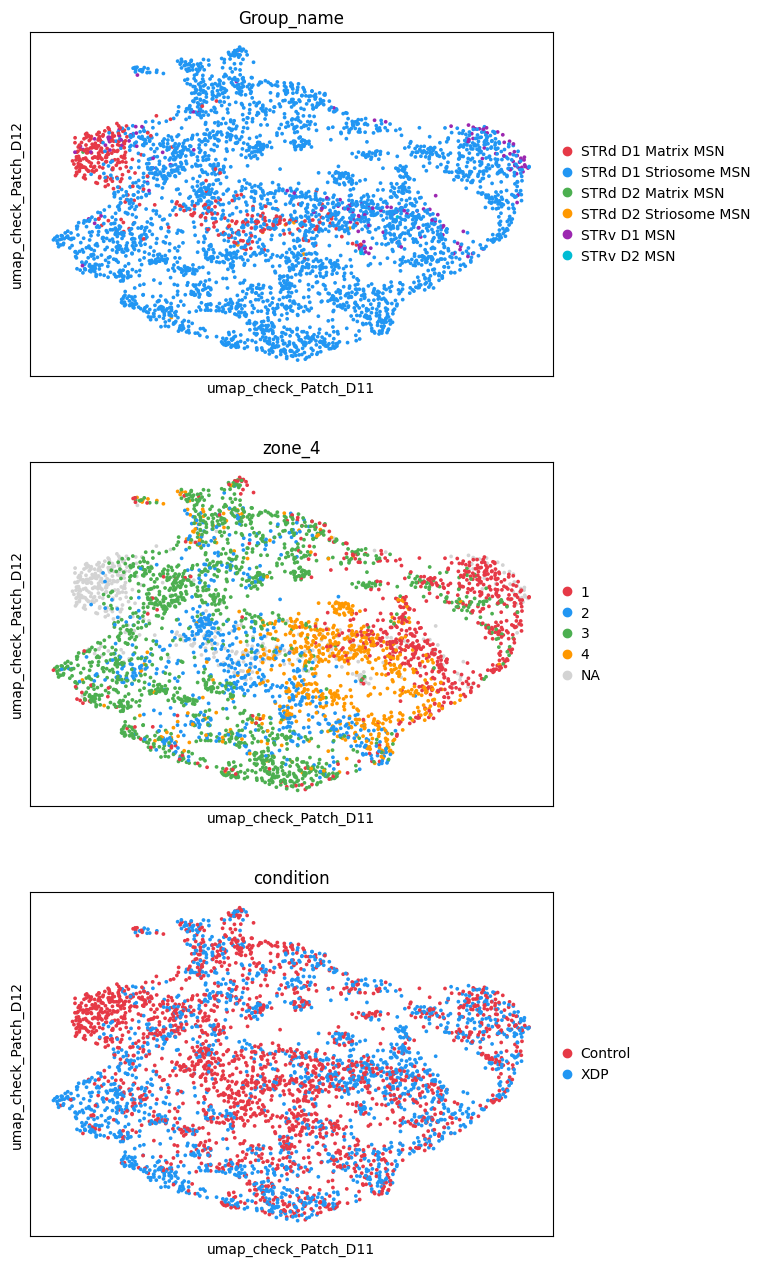

Patch_D2 ['STRd D2 Striosome MSN']


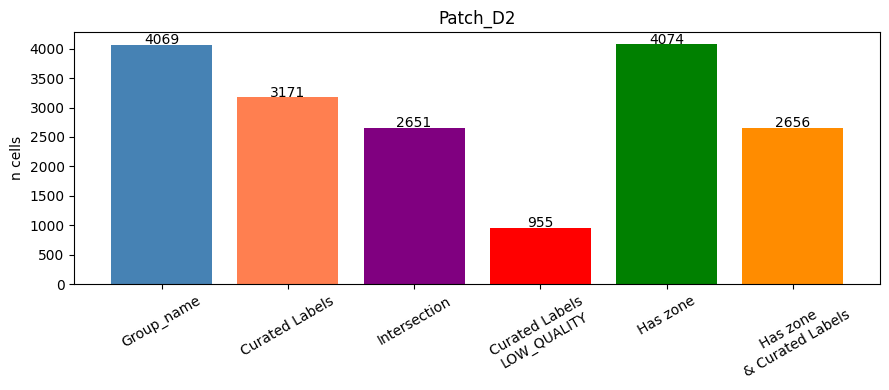

2026-05-13 16:10:04 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-13 16:10:04 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


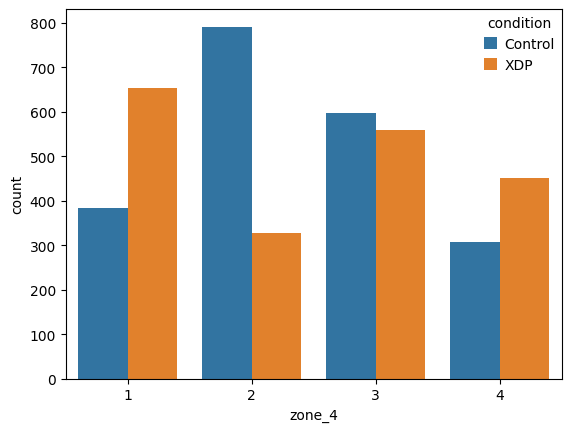

INFO: Seed set to 42
2026-05-13 16:10:05 | [INFO] Seed set to 42


Running HVG...
Subsetting to copy with only HVG...
Scaling ...
Running Harmony...
Running PCA before Harmony...


/home/gdallagl/.pyenv/versions/3.11.8/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
2026-05-13 16:10:10,191 - harmonypy - INFO - Running Harmony (PyTorch on cuda)
2026-05-13 16:10:10 | [INFO] Running Harmony (PyTorch on cuda)
2026-05-13 16:10:10,193 - harmonypy - INFO -   Parameters:
2026-05-13 16:10:10 | [INFO]   Parameters:
2026-05-13 16:10:10,194 - harmonypy - INFO -     max_iter_harmony: 30
2026-05-13 16:10:10 | [INFO]     max_iter_harmony: 30
2026-05-13 16:10:10,195 - harmonypy - INFO -     max_iter_kmeans: 20
2026-05-13 16:10:10 | [INFO]     max_iter_kmeans: 20
2026-05-13 16:10:10,196 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-05-13 16:10:10 | [INFO]     epsilon_cluster: 1e-05
2026-05-13 16:10:10,197 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-05-13 16:10:10 | [INFO]     epsilon_harmony: 0.0001
2026-05-13 16:10:10,199 - harmonypy - INFO -     nclust: 100
2026-0

Running Harmony batch correction...


2026-05-13 16:10:11,549 - harmonypy - INFO - Iteration 2 of 30
2026-05-13 16:10:11 | [INFO] Iteration 2 of 30
2026-05-13 16:10:12,822 - harmonypy - INFO - Iteration 3 of 30
2026-05-13 16:10:12 | [INFO] Iteration 3 of 30
2026-05-13 16:10:14,037 - harmonypy - INFO - Iteration 4 of 30
2026-05-13 16:10:14 | [INFO] Iteration 4 of 30
2026-05-13 16:10:14,728 - harmonypy - INFO - Iteration 5 of 30
2026-05-13 16:10:14 | [INFO] Iteration 5 of 30
2026-05-13 16:10:15,913 - harmonypy - INFO - Iteration 6 of 30
2026-05-13 16:10:15 | [INFO] Iteration 6 of 30
2026-05-13 16:10:17,107 - harmonypy - INFO - Iteration 7 of 30
2026-05-13 16:10:17 | [INFO] Iteration 7 of 30
2026-05-13 16:10:17,875 - harmonypy - INFO - Iteration 8 of 30
2026-05-13 16:10:17 | [INFO] Iteration 8 of 30
2026-05-13 16:10:18,857 - harmonypy - INFO - Iteration 9 of 30
2026-05-13 16:10:18 | [INFO] Iteration 9 of 30
2026-05-13 16:10:19,524 - harmonypy - INFO - Iteration 10 of 30
2026-05-13 16:10:19 | [INFO] Iteration 10 of 30
2026-05-

Z_corr shape: (3171, 50), n_obs: 3171
Computing neighbors on Harmony-corrected PCA...
Computing UMAP...
Computing Leiden clusters...


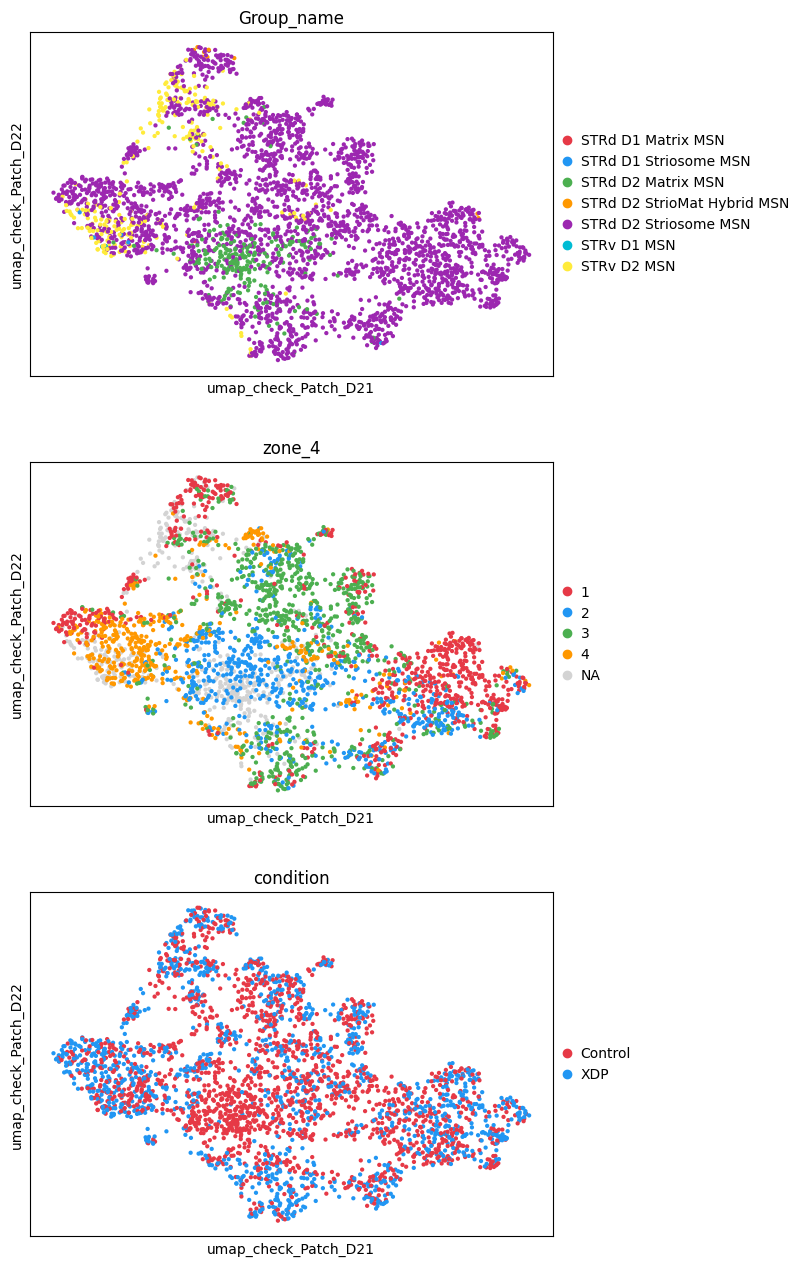

eMSN_D1D2 ['STR D1D2 Hybrid MSN']


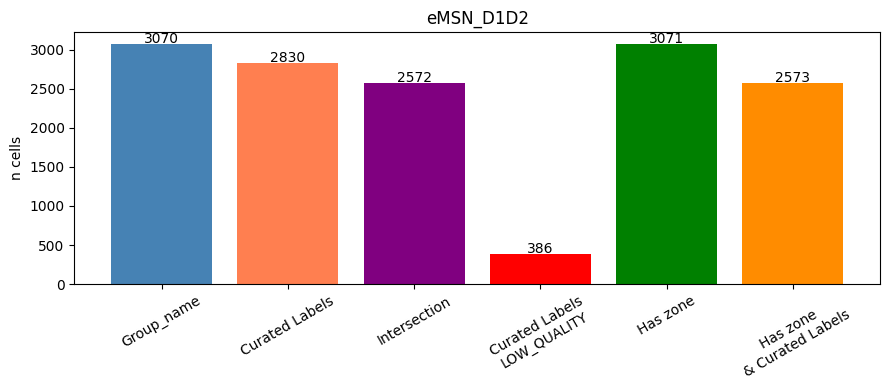

2026-05-13 16:10:45 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-13 16:10:45 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


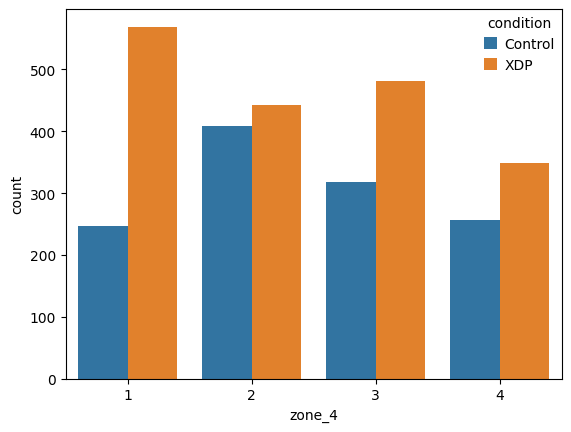

INFO: Seed set to 42
2026-05-13 16:10:46 | [INFO] Seed set to 42


Running HVG...
Subsetting to copy with only HVG...
Scaling ...
Running Harmony...
Running PCA before Harmony...


/home/gdallagl/.pyenv/versions/3.11.8/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
2026-05-13 16:10:50,135 - harmonypy - INFO - Running Harmony (PyTorch on cuda)
2026-05-13 16:10:50 | [INFO] Running Harmony (PyTorch on cuda)
2026-05-13 16:10:50,137 - harmonypy - INFO -   Parameters:
2026-05-13 16:10:50 | [INFO]   Parameters:
2026-05-13 16:10:50,138 - harmonypy - INFO -     max_iter_harmony: 30
2026-05-13 16:10:50 | [INFO]     max_iter_harmony: 30
2026-05-13 16:10:50,139 - harmonypy - INFO -     max_iter_kmeans: 20
2026-05-13 16:10:50 | [INFO]     max_iter_kmeans: 20
2026-05-13 16:10:50,141 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-05-13 16:10:50 | [INFO]     epsilon_cluster: 1e-05
2026-05-13 16:10:50,142 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-05-13 16:10:50 | [INFO]     epsilon_harmony: 0.0001
2026-05-13 16:10:50,143 - harmonypy - INFO -     nclust: 94
2026-05

Running Harmony batch correction...


2026-05-13 16:10:51,453 - harmonypy - INFO - Iteration 2 of 30
2026-05-13 16:10:51 | [INFO] Iteration 2 of 30
2026-05-13 16:10:52,185 - harmonypy - INFO - Iteration 3 of 30
2026-05-13 16:10:52 | [INFO] Iteration 3 of 30
2026-05-13 16:10:52,791 - harmonypy - INFO - Iteration 4 of 30
2026-05-13 16:10:52 | [INFO] Iteration 4 of 30
2026-05-13 16:10:53,544 - harmonypy - INFO - Iteration 5 of 30
2026-05-13 16:10:53 | [INFO] Iteration 5 of 30
2026-05-13 16:10:54,179 - harmonypy - INFO - Iteration 6 of 30
2026-05-13 16:10:54 | [INFO] Iteration 6 of 30
2026-05-13 16:10:55,006 - harmonypy - INFO - Iteration 7 of 30
2026-05-13 16:10:55 | [INFO] Iteration 7 of 30
2026-05-13 16:10:56,165 - harmonypy - INFO - Iteration 8 of 30
2026-05-13 16:10:56 | [INFO] Iteration 8 of 30
2026-05-13 16:10:57,329 - harmonypy - INFO - Iteration 9 of 30
2026-05-13 16:10:57 | [INFO] Iteration 9 of 30
2026-05-13 16:10:57,999 - harmonypy - INFO - Iteration 10 of 30
2026-05-13 16:10:57 | [INFO] Iteration 10 of 30
2026-05-

Z_corr shape: (2830, 50), n_obs: 2830
Computing neighbors on Harmony-corrected PCA...
Computing UMAP...
Computing Leiden clusters...


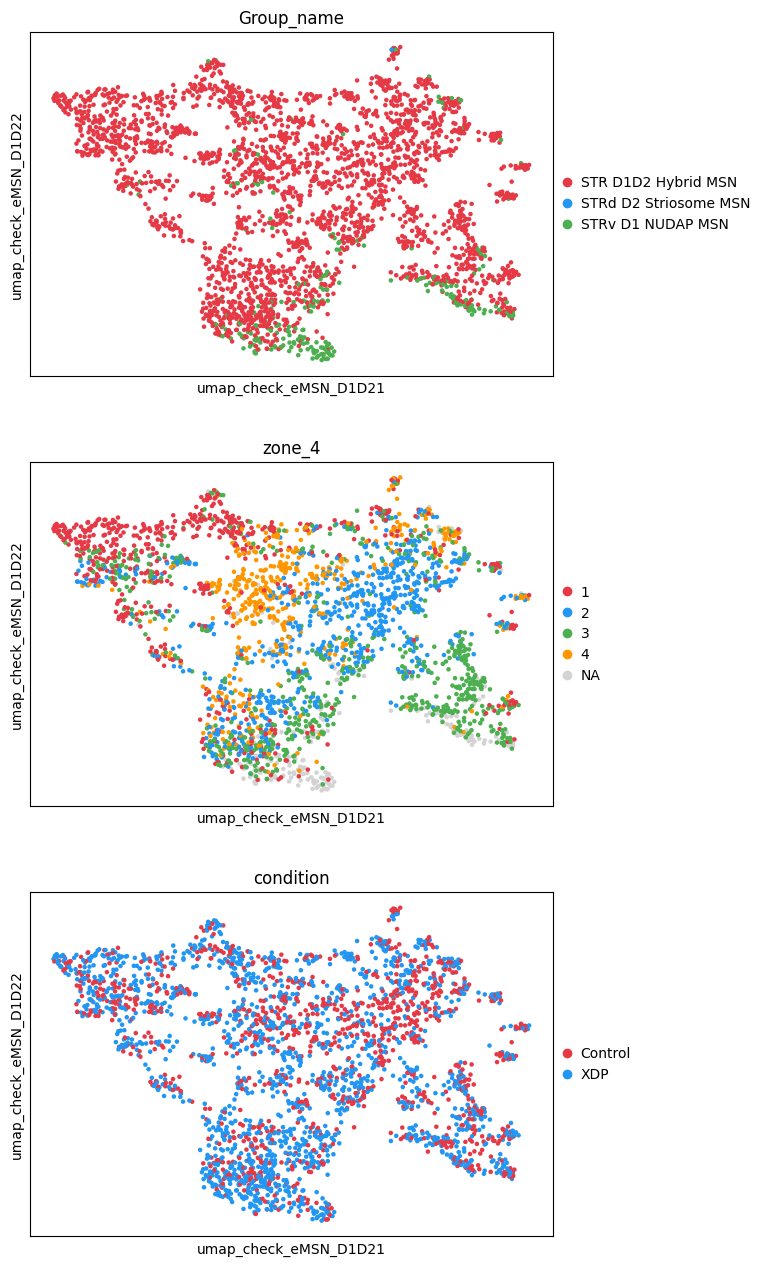

Astrocyte ['Astrocyte']


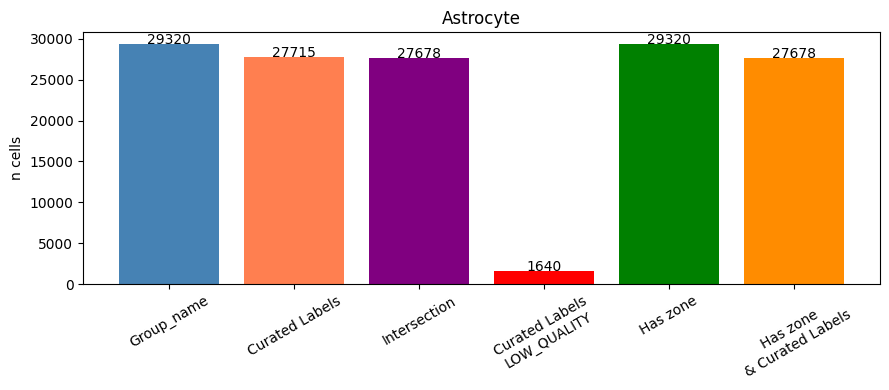

2026-05-13 16:11:15 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-13 16:11:15 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


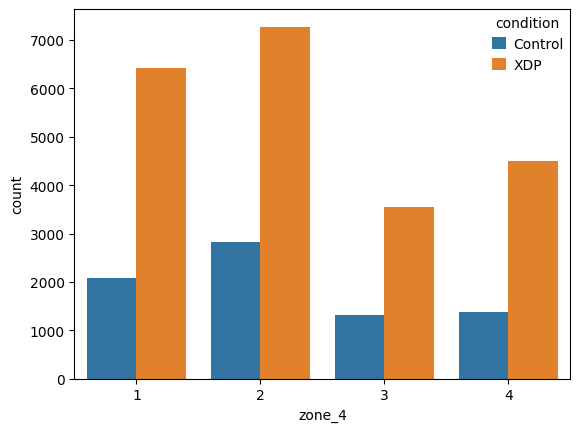

INFO: Seed set to 42
2026-05-13 16:11:18 | [INFO] Seed set to 42


Running HVG...
Subsetting to copy with only HVG...
Scaling ...


/home/gdallagl/.pyenv/versions/3.11.8/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Running Harmony...
Running PCA before Harmony...


2026-05-13 16:11:33,453 - harmonypy - INFO - Running Harmony (PyTorch on cuda)
2026-05-13 16:11:33 | [INFO] Running Harmony (PyTorch on cuda)
2026-05-13 16:11:33,455 - harmonypy - INFO -   Parameters:
2026-05-13 16:11:33 | [INFO]   Parameters:
2026-05-13 16:11:33,456 - harmonypy - INFO -     max_iter_harmony: 30
2026-05-13 16:11:33 | [INFO]     max_iter_harmony: 30
2026-05-13 16:11:33,457 - harmonypy - INFO -     max_iter_kmeans: 20
2026-05-13 16:11:33 | [INFO]     max_iter_kmeans: 20
2026-05-13 16:11:33,458 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-05-13 16:11:33 | [INFO]     epsilon_cluster: 1e-05
2026-05-13 16:11:33,459 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-05-13 16:11:33 | [INFO]     epsilon_harmony: 0.0001
2026-05-13 16:11:33,461 - harmonypy - INFO -     nclust: 100
2026-05-13 16:11:33 | [INFO]     nclust: 100
2026-05-13 16:11:33,462 - harmonypy - INFO -     block_size: 0.05
2026-05-13 16:11:33 | [INFO]     block_size: 0.05
2026-05-13 16:11:33,463 - harm

Running Harmony batch correction...


2026-05-13 16:11:34,075 - harmonypy - INFO - KMeans initialization complete.
2026-05-13 16:11:34 | [INFO] KMeans initialization complete.
2026-05-13 16:11:34,080 - harmonypy - INFO - Iteration 1 of 30
2026-05-13 16:11:34 | [INFO] Iteration 1 of 30
2026-05-13 16:11:35,359 - harmonypy - INFO - Iteration 2 of 30
2026-05-13 16:11:35 | [INFO] Iteration 2 of 30
2026-05-13 16:11:36,603 - harmonypy - INFO - Iteration 3 of 30
2026-05-13 16:11:36 | [INFO] Iteration 3 of 30
2026-05-13 16:11:37,845 - harmonypy - INFO - Iteration 4 of 30
2026-05-13 16:11:37 | [INFO] Iteration 4 of 30
2026-05-13 16:11:39,111 - harmonypy - INFO - Iteration 5 of 30
2026-05-13 16:11:39 | [INFO] Iteration 5 of 30
2026-05-13 16:11:40,377 - harmonypy - INFO - Iteration 6 of 30
2026-05-13 16:11:40 | [INFO] Iteration 6 of 30
2026-05-13 16:11:41,465 - harmonypy - INFO - Iteration 7 of 30
2026-05-13 16:11:41 | [INFO] Iteration 7 of 30
2026-05-13 16:11:42,319 - harmonypy - INFO - Iteration 8 of 30
2026-05-13 16:11:42 | [INFO] 

Z_corr shape: (27715, 50), n_obs: 27715
Computing neighbors on Harmony-corrected PCA...
Computing UMAP...
Computing Leiden clusters...


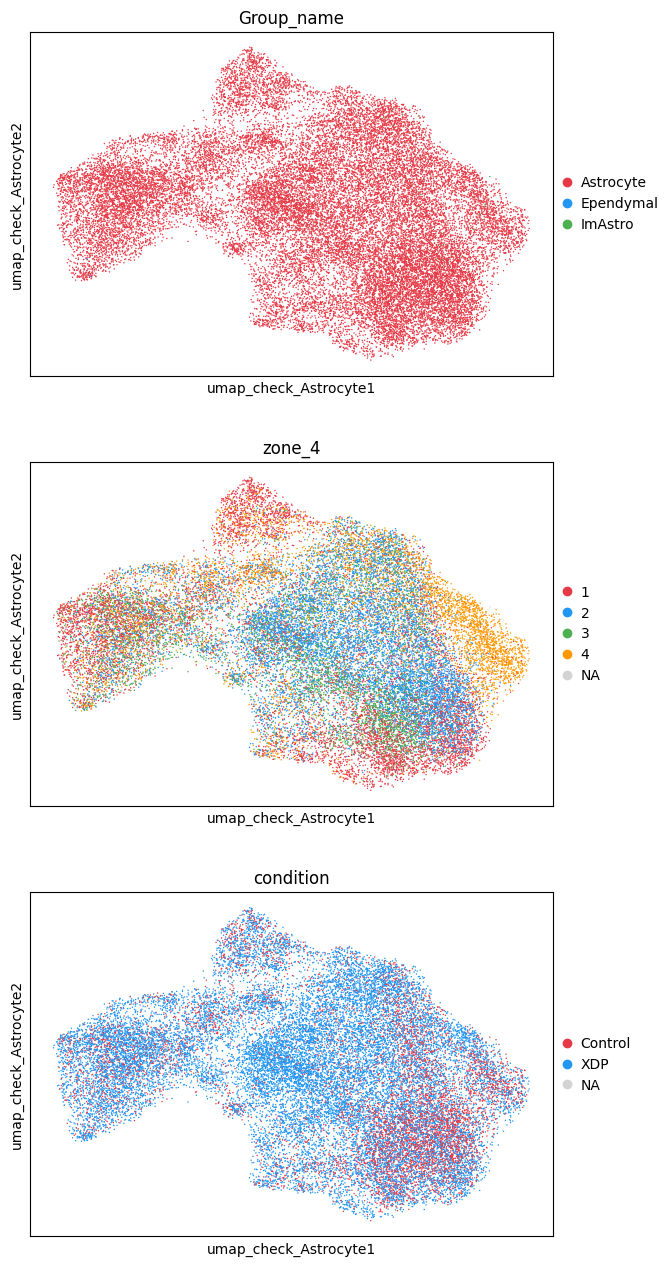

In [24]:
for ct, group, zone_col in [
        ("Matrix_D1", ["STRd D1 Matrix MSN", "STRv D1 MSN"], "zone"), 
        ("Matrix_D2", ["STRd D2 Matrix MSN", "STRv D2 MSN"], "zone"), 
        ("Patch_D1", ["STRd D1 Striosome MSN"], "zone_4"), 
        ("Patch_D2", ["STRd D2 Striosome MSN"], "zone_4"), 
        ("eMSN_D1D2", ["STR D1D2 Hybrid MSN"], "zone_4"), 
        ("Astrocyte", ["Astrocyte"], "zone_4"), 
    ]:

    print(ct, group)

    mask_group = adata.obs["Group_name"].isin(group)
    mask_ct    = adata.obs["Curated Labels"] == ct

    adata_sub = adata[mask_group | mask_ct].copy()
    #display(adata_sub)

    mask_low       = adata_sub.obs["Curated Labels"] == "-Low_quality"
    mask_zone      = adata_sub.obs[zone_col].notna()
    mask_ct_sub    = adata_sub.obs["Curated Labels"] == ct
    mask_zone_ct   = mask_zone & mask_ct_sub

    labels = ["Group_name", "Curated Labels", "Intersection", "Curated Labels\nLOW_QUALITY", "Has zone", "Has zone\n& Curated Labels"]
    counts = [
        mask_group.sum(),
        mask_ct.sum(),
        (mask_group & mask_ct).sum(),
        mask_low.sum(),
        mask_zone.sum(),
        mask_zone_ct.sum(),
    ]
    colors = ["steelblue", "coral", "purple", "red", "green", "darkorange"]

    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.bar(labels, counts, color=colors)
    ax.set_title(ct)
    ax.set_ylabel("n cells")
    for bar, v in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, v + 10, str(v), ha="center")
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()

    sns.countplot(adata_sub.obs, x=zone_col, hue=CONTRAST_VARIABLE); plt.show()

    adata_sub = adata_sub[~((mask_low) | (mask_zone & ~mask_ct_sub))].copy()

    lmu.preprocess_common_pipeline(adata_sub, umap_name=f"_check_{ct}", leiden_name=f"_check_{ct}", resolutions = [0.1], integrate_with_harmony=True, batch_key=SAMPLE_VARIABLE)
    sc.pl.embedding(adata_sub, basis=f"umap_check_{ct}", color=["Group_name", zone_col, CONTRAST_VARIABLE], ncols=1, palette=preprocessing.custom_palette)

    #break

### Per Sample

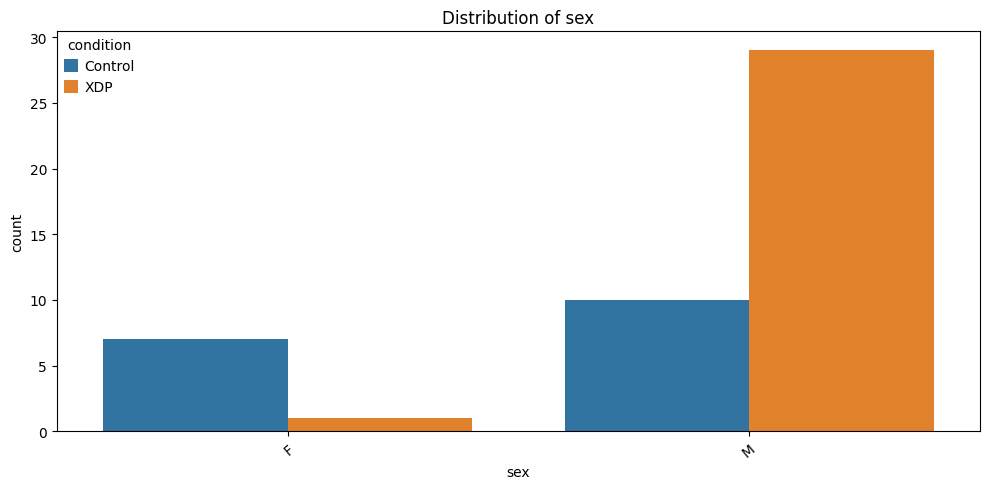

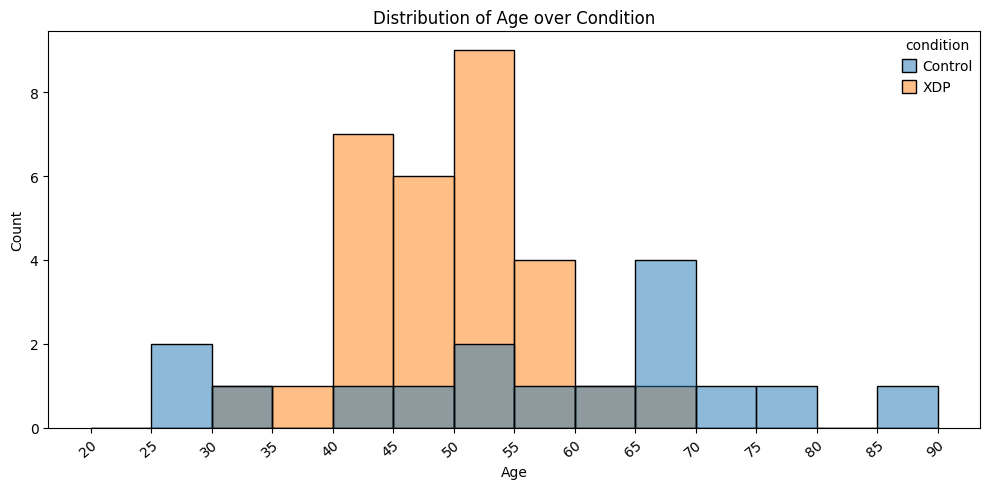

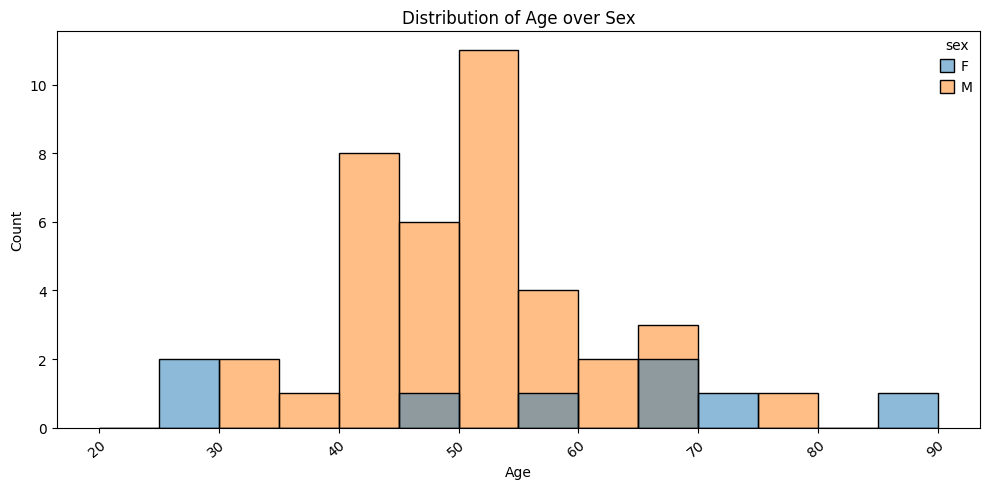

In [21]:

obs = adata.obs.drop_duplicates(subset=SAMPLE_VARIABLE)

figsize = (10,5)
edges = np.arange(20, 91, 5)  # or whatever spacing you want

# counts
plt.figure(figsize=figsize)
sns.countplot(obs, x="sex", hue="condition")
plt.xticks(rotation=40, ha="right", rotation_mode="anchor")
plt.title(f"Distribution of sex")
plt.tight_layout(); plt.show()

# counts
plt.figure(figsize=figsize)
ax = sns.histplot(obs, x="Age", bins=edges, hue="condition")
ax.set_xticks(edges)
plt.xticks(rotation=40, ha="right", rotation_mode="anchor")
plt.title("Distribution of Age over Condition")
plt.tight_layout()
plt.show()

# counts
plt.figure(figsize=figsize)
sns.histplot(obs, x="Age", bins=edges, hue="sex")
plt.xticks(rotation=40, ha="right", rotation_mode="anchor")
plt.title(f"Distribution of Age over Sex")
plt.tight_layout(); plt.show()

# DA --> look in specific folders

# DEG --> look specific folders

# Marker genes overlap for zones --> look notebook